In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import src.helper_function as hf

In [2]:
FIG_DIR = Path("../Visualization/Proportion/")
FIG_DIR.mkdir(parents=True, exist_ok=True)


In [10]:
df = pd.read_parquet(
    path="../data/processed/UCI_Credit_Card_Cleaned.parquet",
    columns=['AGE', 'EDUCATION', 'LIMIT_BAL', 'MARRIAGE', 'SEX', 'IS_DEFAULT']
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   AGE         30000 non-null  int64  
 1   EDUCATION   29986 non-null  object 
 2   LIMIT_BAL   30000 non-null  float64
 3   MARRIAGE    30000 non-null  object 
 4   SEX         30000 non-null  object 
 5   IS_DEFAULT  30000 non-null  int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 1.4+ MB


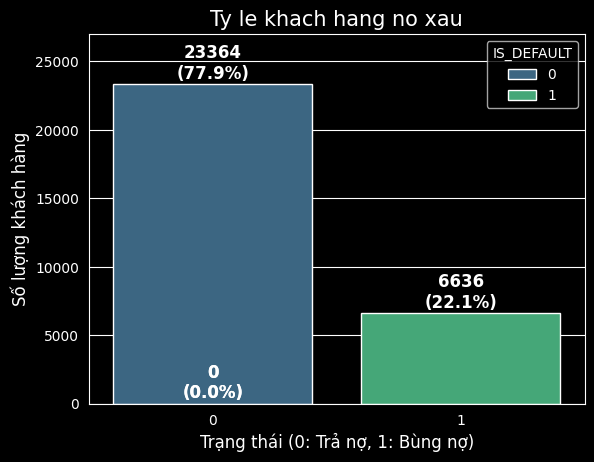

In [4]:
ax = sns.countplot(x='IS_DEFAULT', data=df, palette='viridis', hue="IS_DEFAULT")

# Tinh so dong de tinh %
total = float(len(df))

# Vong lap de chen text len cot
for p in ax.patches:
    # Chieu cao cua cot - so luong
    height = p.get_height()

    # Tinh phan tram
    percentage = '{:.1f}%'.format(100 * height / total)

    ax.annotate(f'{int(height)}\n({percentage})',
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='center',
                xytext=(0, 15),
                textcoords='offset points',
                fontsize=12, fontweight='bold')

plt.title("Ty le khach hang no xau", fontsize=15)
plt.xlabel('Trạng thái (0: Trả nợ, 1: Bùng nợ)', fontsize=12)
plt.ylabel('Số lượng khách hàng', fontsize=12)
plt.ylim(0, total * 0.9)  # Nới rộng trục Y để không bị đè chữ

hf._save_figure_(FIG_DIR, "TyLeKhachHangNoXau")

plt.show()

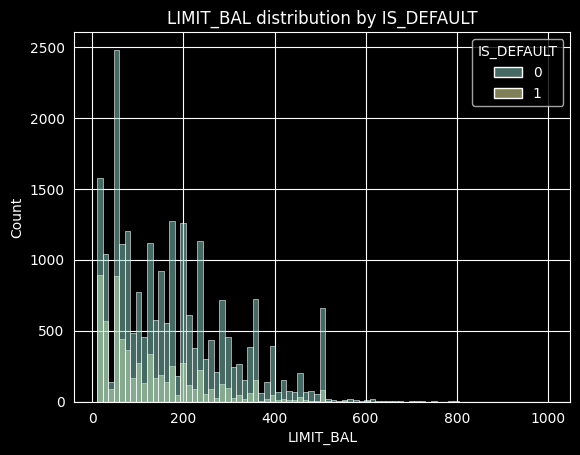

In [5]:
df['LIMIT_BAL'] = df['LIMIT_BAL'] / 1000

# Biều đồ tỷ lệ nợ xấu dựa trên hạn mức tín
hf.plot_hist(df=df, feature='LIMIT_BAL', save_path=FIG_DIR)

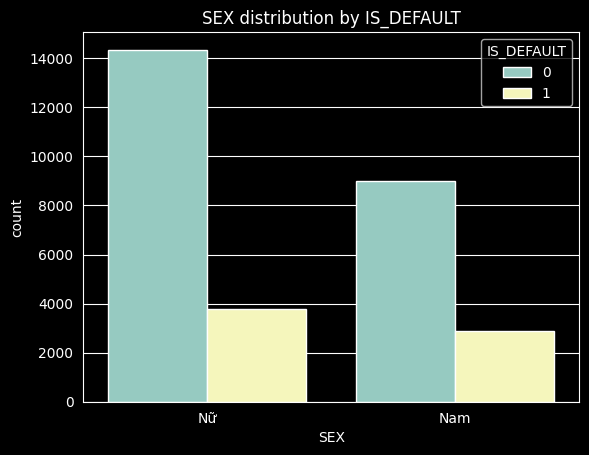

In [6]:
# Biểu đồ tỷ lệ nợ xấu dựa trên giới tính
hf.plot_count(df=df, feature='SEX', save_path=FIG_DIR)

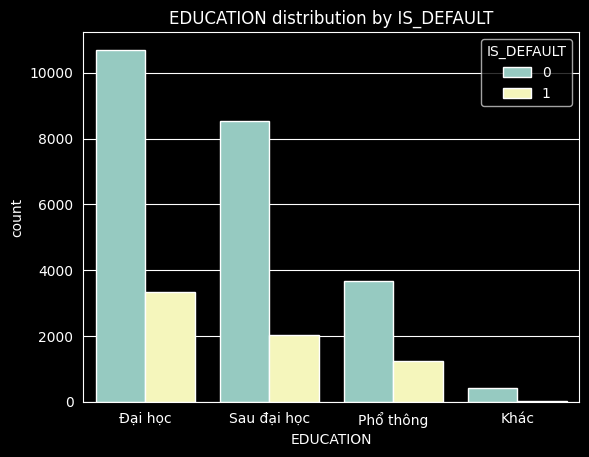

In [7]:
# Biểu đồ tỷ lệ nợ xấu dựa trên trình độ học vấn
hf.plot_count(df=df, feature='EDUCATION', save_path=FIG_DIR)

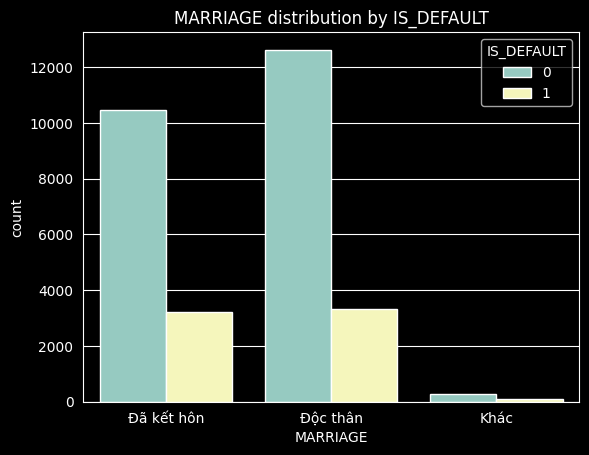

In [8]:
# Ty le no xau dua tren tinh trang hon nhan
hf.plot_count(df=df, feature='MARRIAGE', save_path=FIG_DIR)

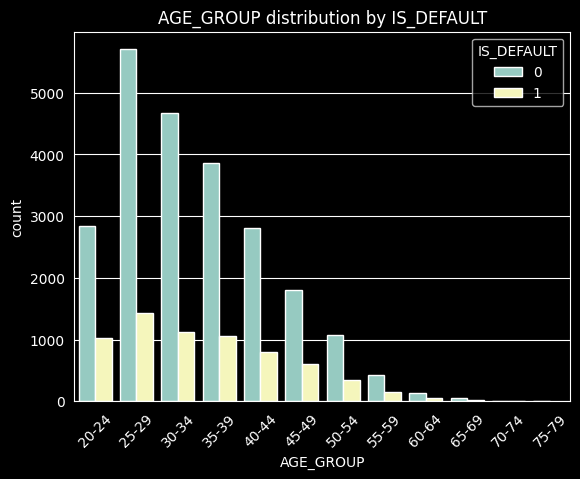

In [9]:
# Tỷ lệ nợ xáu dựa trên số tuổi
# Chia theo nhóm tuổi
bins = list(range(20, 81, 5))  #20, 25, ..., 80
labels = [f"{i}-{i + 4}" for i in bins[:-1]]
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=bins, labels=labels, right=True)

hf.plot_count(df=df, feature='AGE_GROUP', save_path=FIG_DIR, xtick_rotation= 45)